##### Análise dados ENEM 2023

`PARQUET`

DE 0 a 51

PATH: microdados-enem-2023-sp.parquet/part.0.parquet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
import pyarrow as pa

In [2]:
# ler diretorio parquet
ddf = dd.read_parquet('microdados-enem-2023-sp.parquet', engine='pyarrow')

ddf.head()



,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC
0,2.100599e+11,2023.0,3.0,M,0.0,2.0,1.0,0.0,3550308.0,São Paulo,35.0,SP
1,2.100600e+11,2023.0,2.0,F,0.0,2.0,1.0,0.0,3550308.0,São Paulo,35.0,SP
2,2.100596e+11,2023.0,2.0,M,0.0,2.0,1.0,0.0,3505708.0,Barueri,35.0,SP
3,2.100600e+11,2023.0,3.0,F,0.0,2.0,1.0,0.0,3529401.0,Mauá,35.0,SP
4,2.100596e+11,2023.0,2.0,M,0.0,2.0,1.0,0.0,3528403.0,Mairinque,35.0,SP


In [3]:
print(ddf.columns.tolist())

['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC']


Counts antes do map: TP_FAIXA_ETARIA
1.0        535
2.0      76720
3.0     100679
4.0       6663
5.0        788
6.0        197
7.0         92
8.0         88
9.0         80
10.0        77
11.0       286
12.0       190
13.0       191
14.0       173
15.0       124
16.0        85
17.0        64
18.0        22
19.0         8
20.0         5
Name: count, dtype: int64
Counts após map: TP_FAIXA_ETARIA
Menor de 17 anos         535
17 anos                76720
18 anos               100679
19 anos                 6663
20 anos                  788
21 anos                  197
22 anos                   92
23 anos                   88
24 anos                   80
25 anos                   77
Entre 26 e 30 anos       286
Entre 31 e 35 anos       190
Entre 36 e 40 anos       191
Entre 41 e 45 anos       173
Entre 46 e 50 anos       124
Entre 51 e 55 anos        85
Entre 56 e 60 anos        64
Entre 61 e 65 anos        22
Entre 66 e 70 anos         8
Maior de 70 anos           5
Name: count, dtype: int6

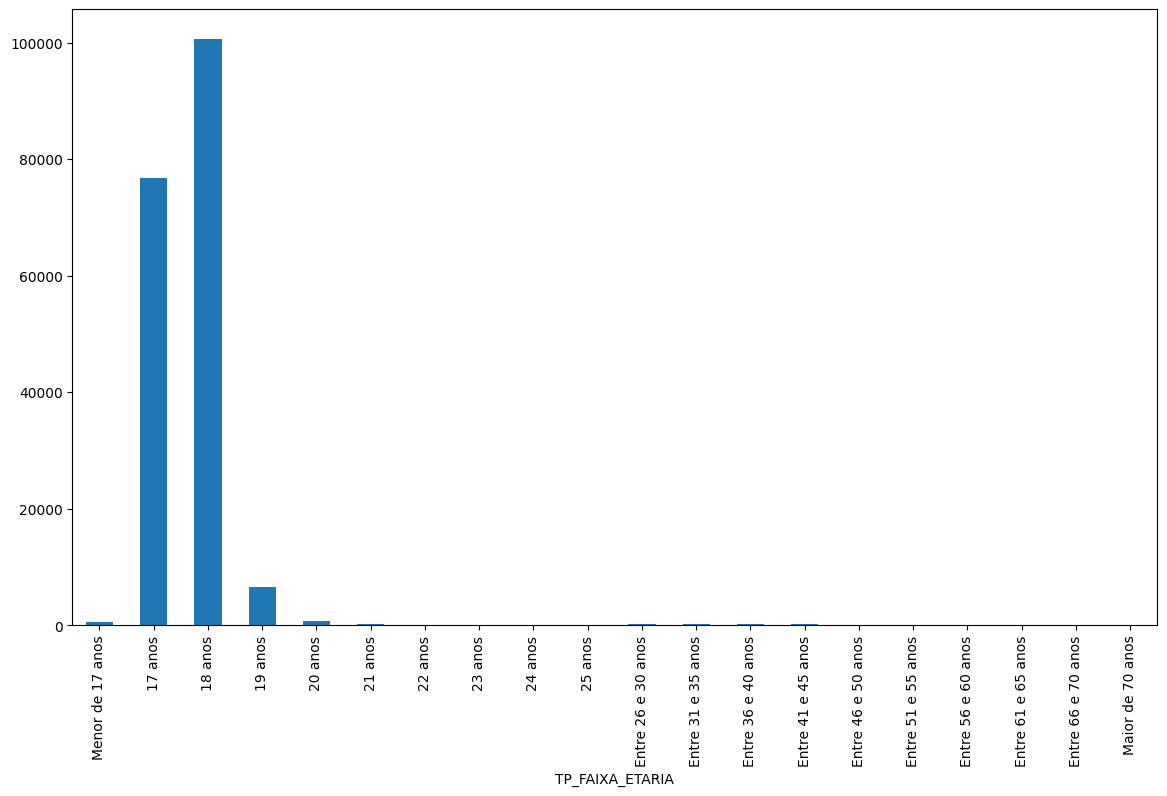

In [ ]:
# Mapeamento para TP_FAIXA_ETARIA
faixa_etaria_map = {
    1: 'Menor de 17 anos',
    2: '17 anos',
    3: '18 anos',
    4: '19 anos',
    5: '20 anos',
    6: '21 anos',
    7: '22 anos',
    8: '23 anos',
    9: '24 anos',
    10: '25 anos',
    11: 'Entre 26 e 30 anos',
    12: 'Entre 31 e 35 anos',
    13: 'Entre 36 e 40 anos',
    14: 'Entre 41 e 45 anos',
    15: 'Entre 46 e 50 anos',
    16: 'Entre 51 e 55 anos',
    17: 'Entre 56 e 60 anos',
    18: 'Entre 61 e 65 anos',
    19: 'Entre 66 e 70 anos',
    20: 'Maior de 70 anos'
}

# Gráfico para TP_FAIXA_ETARIA (Faixa Etária)
if 'TP_FAIXA_ETARIA' in ddf.columns:
    plt.figure(figsize=(14, 8))
    counts = ddf['TP_FAIXA_ETARIA'].value_counts().compute().sort_index()
    # print("Counts antes do map:", counts)
    counts.index = counts.index.map(faixa_etaria_map).fillna('Desconhecido')
    # print("Counts após map:", counts)
    counts.plot(kind='bar')